In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Base folder for all models
MODEL_SAVE_PATH = "/content/drive/MyDrive/SemEval-task-6-main/models"

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(f"{MODEL_SAVE_PATH}/FE", exist_ok=True)


In [2]:
# 1. Imports and configuration

import os
import gc
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    AutoConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Config:
    MODEL_NAME = "microsoft/deberta-v3-base"
    MAX_LENGTH = 512

    SUBTASK1_NUM_LABELS = 3
    SUBTASK2_NUM_LABELS = 9

    SUBTASK1_LABELS = {
        'Clear Reply': 0,
        'Ambivalent': 1,
        'Clear Non-Reply': 2
        }

    SUBTASK2_LABELS = {
        'Explicit': 0,
        'General': 1,
        'Partial/half-answer': 2,
        'Dodging': 3,
        'Implicit': 4,
        'Deflection': 5,
        'Declining to answer': 6,
        'Claims ignorance': 7,
        'Clarification': 8
        }

    BATCH_SIZE = 8
    LEARNING_RATE = 2e-5
    NUM_EPOCHS = 5
    WARMUP_STEPS = 500
    WEIGHT_DECAY = 0.01

    FOCAL_ALPHA = 0.25
    FOCAL_GAMMA = 2.0

    # Paths
    MODEL_SAVE_PATH = "/content/drive/MyDrive/SemEval-task-6-main/models"  # adjust as you like
    OUTPUT_DIR      = "/content/drive/MyDrive/SemEval-task-6-main/results"

config = Config()
print("✓ Configuration loaded successfully!")



✓ Configuration loaded successfully!


In [15]:
# 2. Data loading and label encoding

train_df = pd.read_csv("/content/drive/MyDrive/SemEval-task-6-main/csv_files/FE_training_data.csv")
val_df = pd.read_csv("/content/drive/MyDrive/SemEval-task-6-main/csv_files/FE_validation_data.csv")
test_df = pd.read_csv("/content/drive/MyDrive/SemEval-task-6-main/csv_files/FE_test_data.csv")

# Add numeric label ids if not already present
SUBTASK1_STR_TO_NUM = {
    "Clear Reply": 0,
    "Ambivalent": 1,
    "Clear Non-Reply": 2,
}
SUBTASK2_STR_TO_NUM = {
    "Explicit": 0,
    "General": 1,
    "Partial/half-answer": 2,
    "Dodging": 3,
    "Implicit": 4,
    "Deflection": 5,
    "Declining to answer": 6,
    "Claims ignorance": 7,
    "Clarification": 8,
}

for df in [train_df, val_df, test_df]:
    df["clarity_label_id"] = df["clarity_label"].map(SUBTASK1_STR_TO_NUM)
    df["evasion_label_id"] = df["evasion_label"].map(SUBTASK2_STR_TO_NUM)


In [16]:
#Without FE
class CLARITYDataset(Dataset):
    """Custom Dataset for CLARITY task"""

    def __init__(self, dataframe, tokenizer, max_length, task='subtask1'):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.task = task

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]

        # Concatenate question and answer
        question = str(row['question'])
        interview_answer = str(row['interview_answer'])
        text = f"Question: {question} [SEP] Answer: {interview_answer}"

        # Tokenize
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        # Get label based on task
        if self.task == 'subtask1':
            label = int(row['clarity_label_id'])
        else:
            label = int(row['evasion_label_id'])

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize tokenizer
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
print(f"Tokenizer loaded: {config.MODEL_NAME}")


Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:566: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer loaded: microsoft/deberta-v3-base


In [17]:
class FocalLoss(nn.Module):
    """
    Focal Loss for handling class imbalance
    Reference: https://arxiv.org/abs/1708.02002
    """

    def __init__(self, alpha=0.25, gamma=2.0, num_classes=3):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.num_classes = num_classes

    def forward(self, inputs, targets):
        # Get probabilities
        ce_loss = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        p = torch.exp(-ce_loss)

        # Apply focal term
        focal_loss = self.alpha * (1 - p) ** self.gamma * ce_loss

        return focal_loss.mean()

# Test focal loss
focal_loss_fn = FocalLoss(alpha=config.FOCAL_ALPHA, gamma=config.FOCAL_GAMMA, num_classes=3)
print("Focal Loss initialized")


Focal Loss initialized


In [18]:
class FocalLossTrainer(Trainer):
    """Custom Trainer with Focal Loss - Updated for gradient handling"""

    def __init__(self, focal_loss_fn, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.focal_loss_fn = focal_loss_fn

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        """
        Compute loss with focal loss function.
        """
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # Compute focal loss
        loss = self.focal_loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

print("✓ FocalLossTrainer fixed")


✓ FocalLossTrainer fixed


In [19]:
def compute_metrics(eval_pred):
    """Compute evaluation metrics"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    # Macro F1 (primary metric for SemEval)
    macro_f1 = f1_score(labels, predictions, average='macro')
    micro_f1 = f1_score(labels, predictions, average='micro')
    weighted_f1 = f1_score(labels, predictions, average='weighted')

    # Per-class F1
    per_class_f1 = f1_score(labels, predictions, average=None)

    metrics = {
        'macro_f1': macro_f1,
        'micro_f1': micro_f1,
        'weighted_f1': weighted_f1,
    }

    # Add per-class metrics
    for idx, f1 in enumerate(per_class_f1):
        metrics[f'class_{idx}_f1'] = f1

    return metrics

print("Metrics function ready")


Metrics function ready


In [20]:
# Clear GPU memory before training
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

# Check available memory
if torch.cuda.is_available():
    print(f"GPU Memory before training:")
    print(f"  Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"  Reserved: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
    print(f"  Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9:.2f} GB")

GPU Memory before training:
  Allocated: 0.00 GB
  Reserved: 0.00 GB
  Free: 15.83 GB


In [21]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn

def train_model(train_df, val_df, task='subtask1', model_save_path=None):
    """Train with class weighting to handle imbalance"""

    import gc

    print(f"\n{'='*60}")
    print(f"Training Model for {task.upper()} WITH CLASS WEIGHTS")
    print(f"{'='*60}")

    # Clear cache
    torch.cuda.empty_cache()
    gc.collect()

    # Get label column and num_labels
    if task == 'subtask1':
        label_col = 'clarity_label_id'
        num_labels = config.SUBTASK1_NUM_LABELS
    else:
        label_col = 'evasion_label_id'
        num_labels = config.SUBTASK2_NUM_LABELS

    # Compute class weights from train_df
    unique_classes = sorted(train_df[label_col].unique())
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.array(unique_classes),
        y=train_df[label_col]
    )

    # Full weight tensor
    weights_full = torch.ones(num_labels, dtype=torch.float32)
    for cls, weight in zip(unique_classes, class_weights):
        weights_full[int(cls)] = float(weight)

    weights_full = weights_full.to(device)

    print(f"\n⚖️ Class weights:")
    for i, weight in enumerate(weights_full):
        print(f"   Class {i}: {weight:.3f}")

    # Load model
    print(f"\nLoading model: {config.MODEL_NAME}")
    model = AutoModelForSequenceClassification.from_pretrained(
        config.MODEL_NAME,
        num_labels=num_labels,
        problem_type="single_label_classification"
    )
    model.to(device)

    # >>> Wrap your existing DataFrames in CLARITYDataset <<<
    #Without FE
    print("Creating datasets from DataFrames...")
    train_dataset = CLARITYDataset(train_df, tokenizer, config.MAX_LENGTH, task=task)
    val_dataset   = CLARITYDataset(val_df,   tokenizer, config.MAX_LENGTH, task=task)
    print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


    # model = TransformerWithFeatures(
    # base_model_name=config.MODEL_NAME,
    # num_labels=num_labels,
    # feature_dim=FEATURE_DIM).to(device)

    #With FE
    # print("Creating datasets from DataFrames...")
    # train_dataset = CLARITYDataset(train_df, tokenizer, config.MAX_LENGTH, task='subtask1', return_features=True)
    # val_dataset   = CLARITYDataset(val_df,   tokenizer, config.MAX_LENGTH, task='subtask1', return_features=True)
    # print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


    # Custom Trainer with weighted loss
    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits

            loss_fct = nn.CrossEntropyLoss(weight=weights_full)
            loss = loss_fct(logits.view(-1, num_labels), labels.view(-1))
            return (loss, outputs) if return_outputs else loss


    # class WeightedTrainer(Trainer):
    #   def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
    #     labels = inputs.pop("labels")
    #     extra_features = inputs.pop("extra_features", None)  # [B, F] or None
    #     outputs = model(
    #         input_ids=inputs["input_ids"],
    #         attention_mask=inputs["attention_mask"],
    #         extra_features=extra_features,
    #         labels=labels
    #         )
    #     loss = outputs["loss"]
    #     return (loss, outputs) if return_outputs else loss


    output_dir = f"{config.OUTPUT_DIR}/{task}_weighted"

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=config.NUM_EPOCHS,
        per_device_train_batch_size=config.BATCH_SIZE,
        per_device_eval_batch_size=config.BATCH_SIZE,
        learning_rate=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY,
        warmup_steps=config.WARMUP_STEPS,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        logging_steps=50,
        save_total_limit=1,
        seed=SEED,
        fp16=True,
        report_to="none",
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
    )

    print("\nTraining with class weights...")
    train_result = trainer.train()

    # Save
    if model_save_path:
        trainer.save_model(model_save_path)
        tokenizer.save_pretrained(model_save_path)

    # Evaluate
    print("\nEvaluating...")
    eval_results = trainer.evaluate()

    print("\nResults:")
    print(f"   Macro F1: {eval_results['eval_macro_f1']:.4f}")
    print(f"   Weighted F1: {eval_results['eval_weighted_f1']:.4f}")

    # Prediction diversity on validation Dataset
    predictions = trainer.predict(val_dataset)
    preds = np.argmax(predictions.predictions, axis=1)
    unique_preds = len(np.unique(preds))
    print(f"   Predicting {unique_preds} different classes")

    torch.cuda.empty_cache()
    gc.collect()

    return trainer, model, eval_results

print("✓ Weighted training function ready")


✓ Weighted training function ready


In [22]:
# Train Subtask 1
print("="*80)
print("TRAINING SUBTASK 1: CLARITY LEVEL CLASSIFICATION")
print("="*80)


trainer_subtask1, model_subtask1, results_subtask1 = train_model(
    train_df=train_df,
    val_df=val_df,
    task='subtask1',
    model_save_path=f"{config.MODEL_SAVE_PATH}/without_FE/subtask1"
)

TRAINING SUBTASK 1: CLARITY LEVEL CLASSIFICATION

Training Model for SUBTASK1 WITH CLASS WEIGHTS

⚖️ Class weights:
   Class 0: 1.093
   Class 1: 0.563
   Class 2: 3.229

Loading model: microsoft/deberta-v3-base


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Creating datasets from DataFrames...
Train: 2344, Val: 414

🚀 Training with class weights...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Weighted F1,Class 0 F1,Class 1 F1,Class 2 F1
1,1.041600,1.111163,0.377117,0.560386,0.495616,0.106667,0.731107,0.293578
2,0.896900,1.235019,0.237550,0.316425,0.176064,0.470363,0.015873,0.226415
3,0.798400,0.998605,0.395421,0.393720,0.308484,0.508403,0.170819,0.507042
4,0.667100,0.856225,0.630784,0.676329,0.676237,0.578512,0.745418,0.568421
5,0.588200,0.947630,0.609309,0.664251,0.663607,0.576000,0.734280,0.517647



Evaluating...



✅ Results:
   Macro F1: 0.6308
   Weighted F1: 0.6762
   Predicting 3 different classes


In [23]:
print("="*80)
print("TRAINING SUBTASK 2: EVASION LEVEL CLASSIFICATION")
print("="*80)

trainer_subtask2, model_subtask2, results_subtask2 = train_model(
    train_df=train_df,          # evasion training dataframe
    val_df=val_df,              # evasion validation dataframe
    task='subtask2',
    model_save_path=f"{config.MODEL_SAVE_PATH}/without_FE/subtask2"
)



TRAINING SUBTASK 2: EVASION LEVEL CLASSIFICATION

Training Model for SUBTASK2 WITH CLASS WEIGHTS

⚖️ Class weights:
   Class 0: 0.364
   Class 1: 0.987
   Class 2: 4.914
   Class 3: 0.548
   Class 4: 0.764
   Class 5: 1.025
   Class 6: 2.771
   Class 7: 3.101
   Class 8: 4.069

Loading model: microsoft/deberta-v3-base


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Creating datasets from DataFrames...
Train: 2344, Val: 414

🚀 Training with class weights...


Epoch,Training Loss,Validation Loss,Macro F1,Micro F1,Weighted F1,Class 0 F1,Class 1 F1,Class 2 F1,Class 3 F1,Class 4 F1,Class 5 F1,Class 6 F1,Class 7 F1,Class 8 F1
1,2.084200,2.172612,0.074445,0.149758,0.087256,0.029197,0.000000,0.000000,0.180451,0.225064,0.000000,0.235294,0.000000,0.000000
2,1.991100,2.081646,0.138007,0.282609,0.215103,0.455782,0.000000,0.000000,0.145161,0.000000,0.296296,0.000000,0.000000,0.344828
3,1.756500,1.963990,0.179816,0.314010,0.194913,0.487912,0.000000,0.000000,0.041237,0.000000,0.030303,0.258065,0.274510,0.526316
4,1.583600,1.759979,0.319447,0.304348,0.305087,0.451923,0.202381,0.000000,0.169492,0.192982,0.252427,0.510638,0.486486,0.608696
5,1.564100,1.753693,0.321742,0.323671,0.321728,0.473934,0.085714,0.000000,0.222222,0.267380,0.276423,0.523810,0.437500,0.608696



Evaluating...



✅ Results:
   Macro F1: 0.3217
   Weighted F1: 0.3217
   Predicting 9 different classes


In [26]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def evaluate_and_visualize(trainer, model, test_df, task):
    """Evaluation with ids only (no label name mapping)."""
    print(f"\n{'='*60}")
    print(f"Detailed Evaluation for {task.upper()}")
    print(f"{'='*60}")

    # Build test dataset
    test_dataset = CLARITYDataset(test_df, tokenizer, config.MAX_LENGTH, task=task)

    # Get predictions
    predictions = trainer.predict(test_dataset)
    pred_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = predictions.label_ids

    # Classification report (uses label ids)
    print("\nClassification Report (label ids):")
    print(classification_report(true_labels, pred_labels, digits=4))

    # Confusion matrix
    cm = confusion_matrix(true_labels, pred_labels)
    labels = sorted(np.unique(true_labels))

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels
    )
    plt.title(f'Confusion Matrix - {task.upper()}', fontsize=16, fontweight='bold')
    plt.ylabel('True Label (id)', fontsize=12)
    plt.xlabel('Predicted Label (id)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{task}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Per-class F1 (indexed by label id)
    per_class_f1 = f1_score(true_labels, pred_labels, average=None, labels=labels)

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(len(labels)), per_class_f1, color='steelblue', alpha=0.7)
    plt.xlabel('Class ID', fontsize=12)
    plt.ylabel('F1 Score', fontsize=12)
    plt.title(f'Per-Class F1 Scores - {task.upper()}', fontsize=16, fontweight='bold')
    plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for i, (bar, score) in enumerate(zip(bars, per_class_f1)):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{score:.3f}', ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'per_class_f1_{task}.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Aggregate metrics
    metrics = {
        'macro_f1': f1_score(true_labels, pred_labels, average='macro'),
        'micro_f1': f1_score(true_labels, pred_labels, average='micro'),
        'weighted_f1': f1_score(true_labels, pred_labels, average='weighted'),
        'per_class_f1': per_class_f1,
        'confusion_matrix': cm
    }

    return metrics, pred_labels



Detailed Evaluation for SUBTASK1



Classification Report (label ids):
              precision    recall  f1-score   support

           0     0.5970    0.5687    0.5825       211
           1     0.7475    0.7475    0.7475       408
           2     0.5679    0.6479    0.6053        71

    accuracy                         0.6826       690
   macro avg     0.6375    0.6547    0.6451       690
weighted avg     0.6830    0.6826    0.6824       690



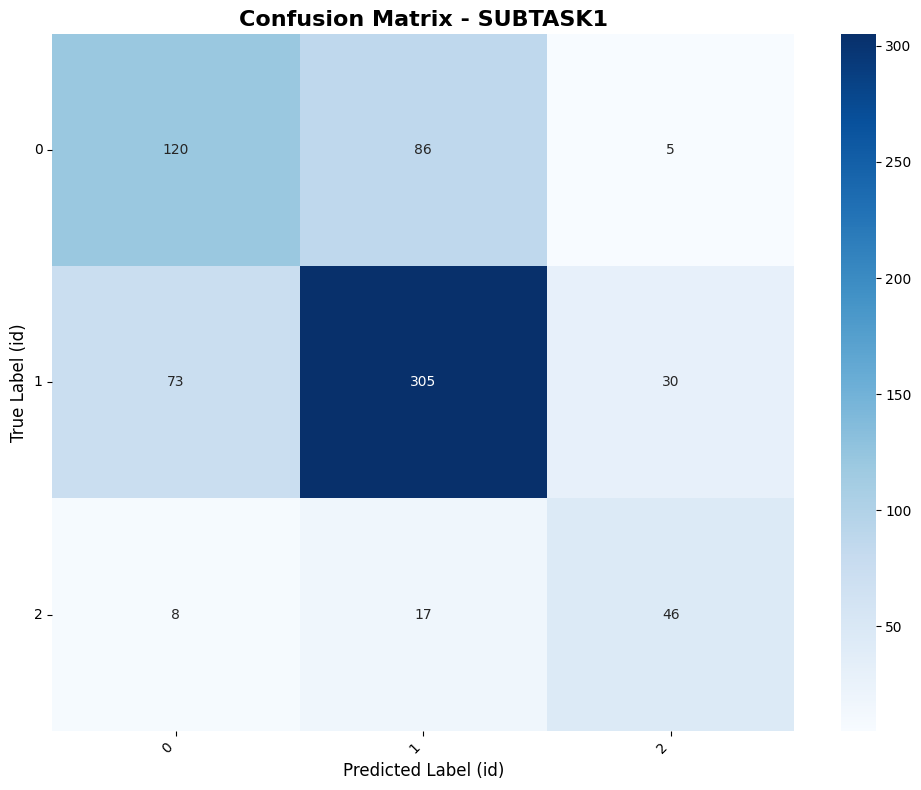

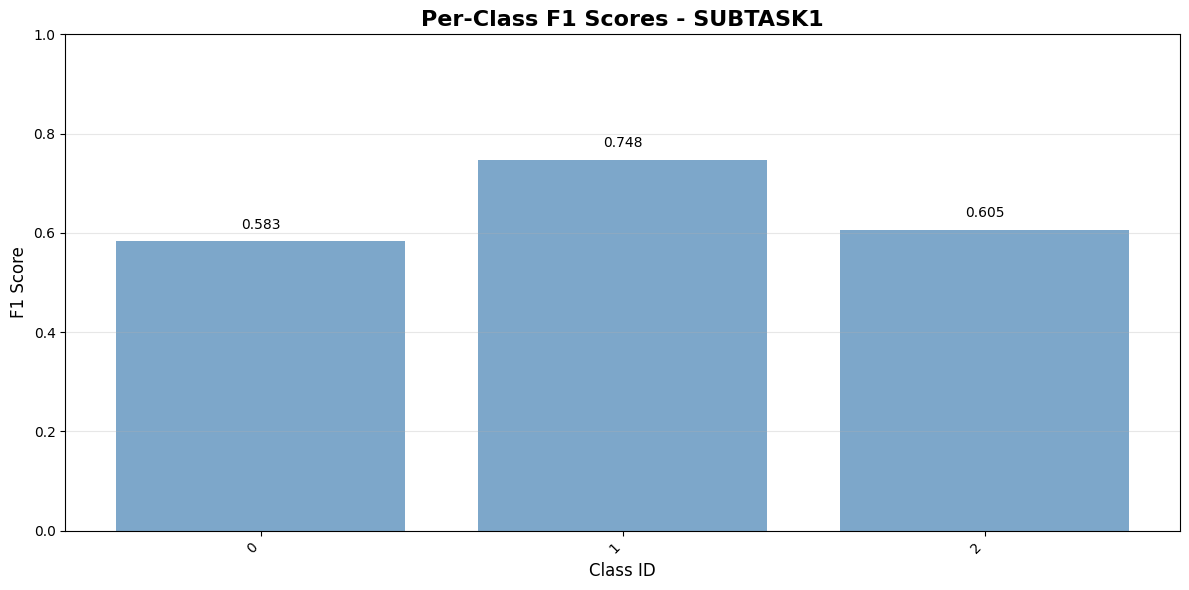

In [27]:
# Evaluate Subtask 1 on test set
metrics_subtask1, preds_subtask1 = evaluate_and_visualize(
    trainer_subtask1,
    model_subtask1,
    test_df,
    task='subtask1'
)


Detailed Evaluation for SUBTASK2



Classification Report (label ids):
              precision    recall  f1-score   support

           0     0.5583    0.4313    0.4866       211
           1     0.2083    0.1299    0.1600        77
           2     0.0000    0.0000    0.0000        16
           3     0.3258    0.2057    0.2522       141
           4     0.2216    0.4388    0.2945        98
           5     0.2018    0.2895    0.2378        76
           6     0.4000    0.4828    0.4375        29
           7     0.3704    0.4167    0.3922        24
           8     0.5652    0.7222    0.6341        18

    accuracy                         0.3362       690
   macro avg     0.3168    0.3463    0.3217       690
weighted avg     0.3587    0.3362    0.3348       690



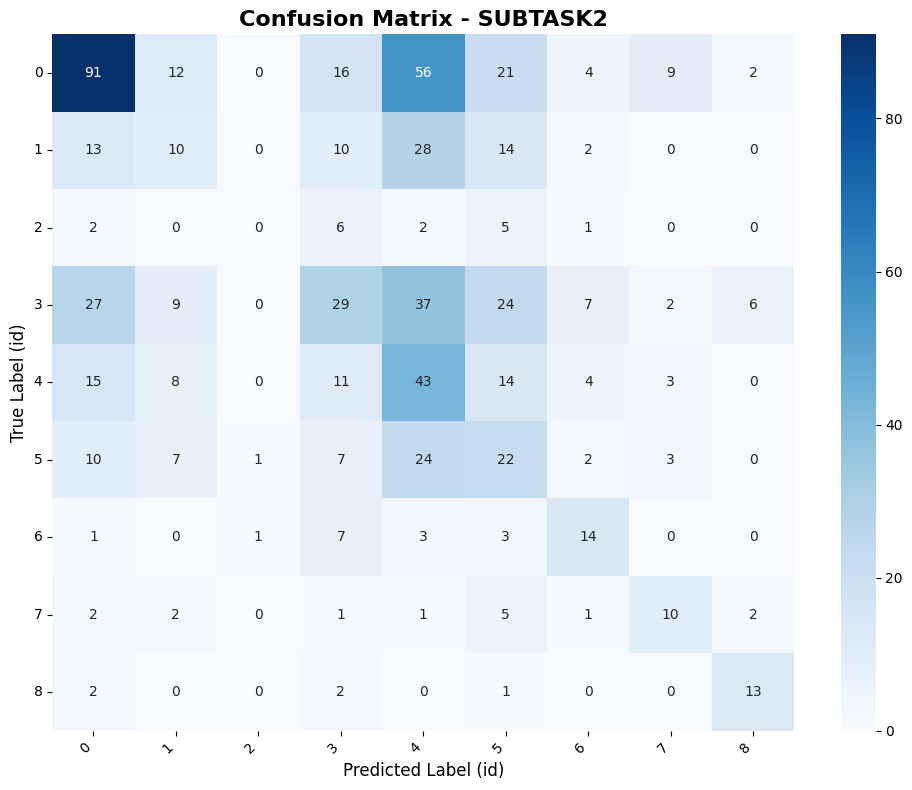

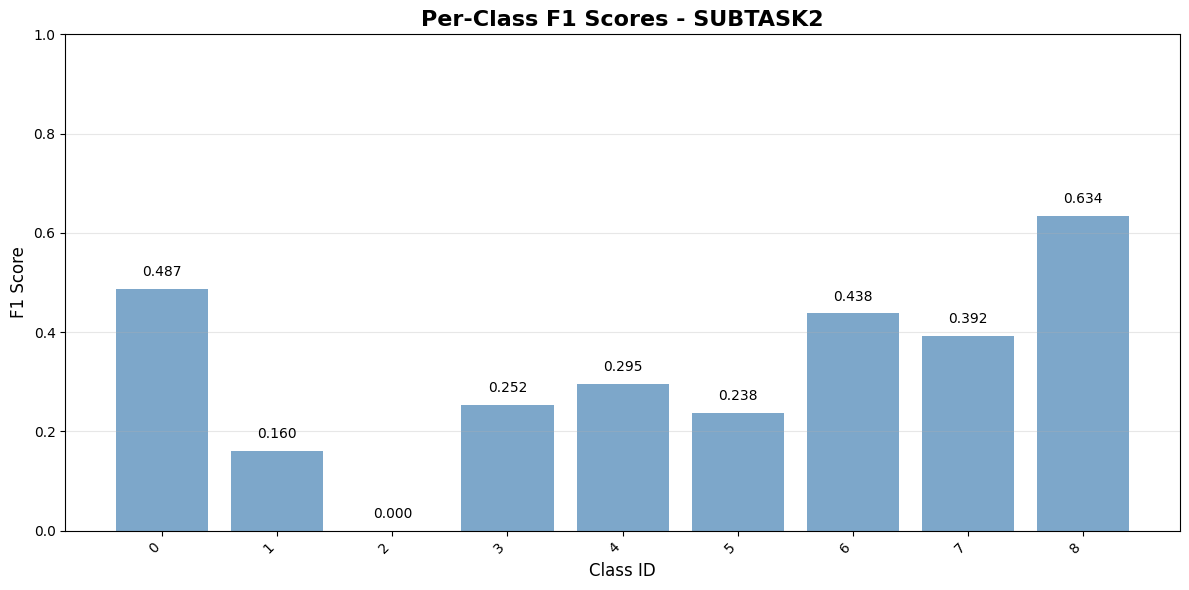

In [28]:
metrics_subtask2, preds_subtask2 = evaluate_and_visualize(
    trainer_subtask2,
    model_subtask2,
    test_df,
    task='subtask2'
)

In [5]:
print(config.MODEL_SAVE_PATH)
!ls -R "{config.MODEL_SAVE_PATH}"

/content/drive/MyDrive/SemEval-task-6-main/models
ls: cannot access '/content/drive/MyDrive/SemEval-task-6-main/models': No such file or directory
